# 🏠 Housing Price Prediction: ML for Property Valuation & Affordability Policy

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting housing prices from property features to support affordability analysis and valuation  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting property prices using structural features (area, bedrooms, bathrooms, stories), amenities, and location characteristics. The model supports **automated property valuation**, **affordability analysis**, and **stamp duty revenue forecasting**.

### Government Policy Context
- **Treasury** — Housing affordability policy, First Home Owner Grant targeting, stamp duty reform modelling
- **NHFIC / Housing Australia** — Housing supply forecasting, Help to Buy scheme eligibility, regional price analytics
- **ABS** — Residential Property Price Index, census-linked housing analysis
- **APRA** — Mortgage lending standards, LVR restrictions, macroprudential policy, serviceability buffers
- **State Revenue Offices** — Stamp duty revenue forecasting, land tax base estimation

### Operational Decision Framework
| Use Case | Action | Stakeholder |
|-----------|--------|-------------|
| Automated valuation (AVM) | Generate comparable-adjusted price estimate | Bank / mortgage assessor |
| Affordability assessment | Flag properties within FHOG/Help to Buy thresholds | Housing Australia |
| Revenue forecasting | Estimate stamp duty yield from transaction volumes | State Treasury |
| Market monitoring | Detect price anomalies, bubble indicators | APRA / RBA |

---

**Note:** This is a **regression** notebook — predicting continuous price. Metrics: RMSE, MAE, R².


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY — REGRESSION MODE")
print("=" * 60)


ENVIRONMENT READY — REGRESSION MODE


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv

Loaded: 545 rows x 13 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    if df[col].dtype in ['int64', 'float64']:
        print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | range=[{df[col].min():,.0f}, {df[col].max():,.0f}]")
    else:
        sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
        print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. price                          | int64      | unique=   219 | nulls=  0 | range=[1,750,000, 13,300,000]
   1. area                           | int64      | unique=   284 | nulls=  0 | range=[1,650, 16,200]
   2. bedrooms                       | int64      | unique=     6 | nulls=  0 | range=[1, 6]
   3. bathrooms                      | int64      | unique=     4 | nulls=  0 | range=[1, 4]
   4. stories                        | int64      | unique=     4 | nulls=  0 | range=[1, 4]
   5. mainroad                       | object     | unique=     2 | nulls=  0 | eg: yes
   6. guestroom                      | object     | unique=     2 | nulls=  0 | eg: no
   7. basement                       | object     | unique=     2 | nulls=  0 | eg: no
   8. hotwaterheating                | object     | unique=     2 | nulls=  0 | eg: no
   9. airconditioning                | object     | unique=     2 | nulls=  0 | eg: yes
  10. parking                        | int64      | uniqu

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['price', 'Price', 'SalePrice', 'saleprice', 'median_house_value',
                     'Target', 'target', 'value', 'Value', 'PRICE']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break
if target_col is None:
    for col in df.columns:
        if any(kw in col.lower() for kw in ['price', 'value', 'cost']) and df[col].dtype in ['int64', 'float64']:
            target_col = col
            print(f"Auto-detected: '{target_col}'")
            break
if target_col is None:
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        target_col = num_cols[-1]
        print(f"Fallback: '{target_col}'")
if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nStatistics:")
print(df[target_col].describe())


Found target: 'price'

Statistics:
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


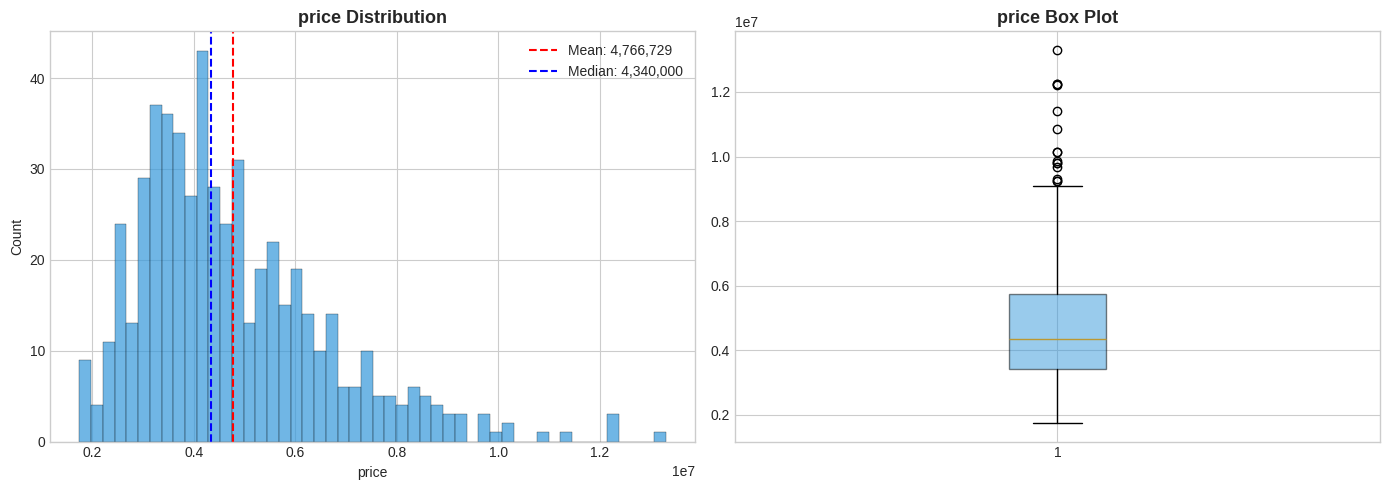

Skewness: 1.212
Highly skewed — log transform recommended.

AU context: Median dwelling price ~$780K nationally (CoreLogic 2024).
Sydney ~$1.15M, Melbourne ~$780K, Brisbane ~$780K. Affordability is a key policy issue.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[target_col].dropna(), bins=50, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_title(f'{target_col} Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel(target_col); axes[0].set_ylabel('Count')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():,.0f}')
axes[0].axvline(df[target_col].median(), color='blue', linestyle='--', label=f'Median: {df[target_col].median():,.0f}')
axes[0].legend()
axes[1].boxplot(df[target_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.5))
axes[1].set_title(f'{target_col} Box Plot', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
skewness = df[target_col].skew()
print(f"Skewness: {skewness:.3f}")
if abs(skewness) > 1:
    print("Highly skewed — log transform recommended.")
print("\nAU context: Median dwelling price ~$780K nationally (CoreLogic 2024).")
print("Sydney ~$1.15M, Melbourne ~$780K, Brisbane ~$780K. Affordability is a key policy issue.")


## 3. Exploratory Data Analysis

Key questions for housing policy:
- Which property features drive price the most (area, bedrooms, location)?
- Are there diminishing returns (e.g., 4th bedroom adds less than 3rd)?
- How do amenities (aircon, parking, furnishing) affect premium?
- What's the price-per-sqm distribution?


Numeric features (5): ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


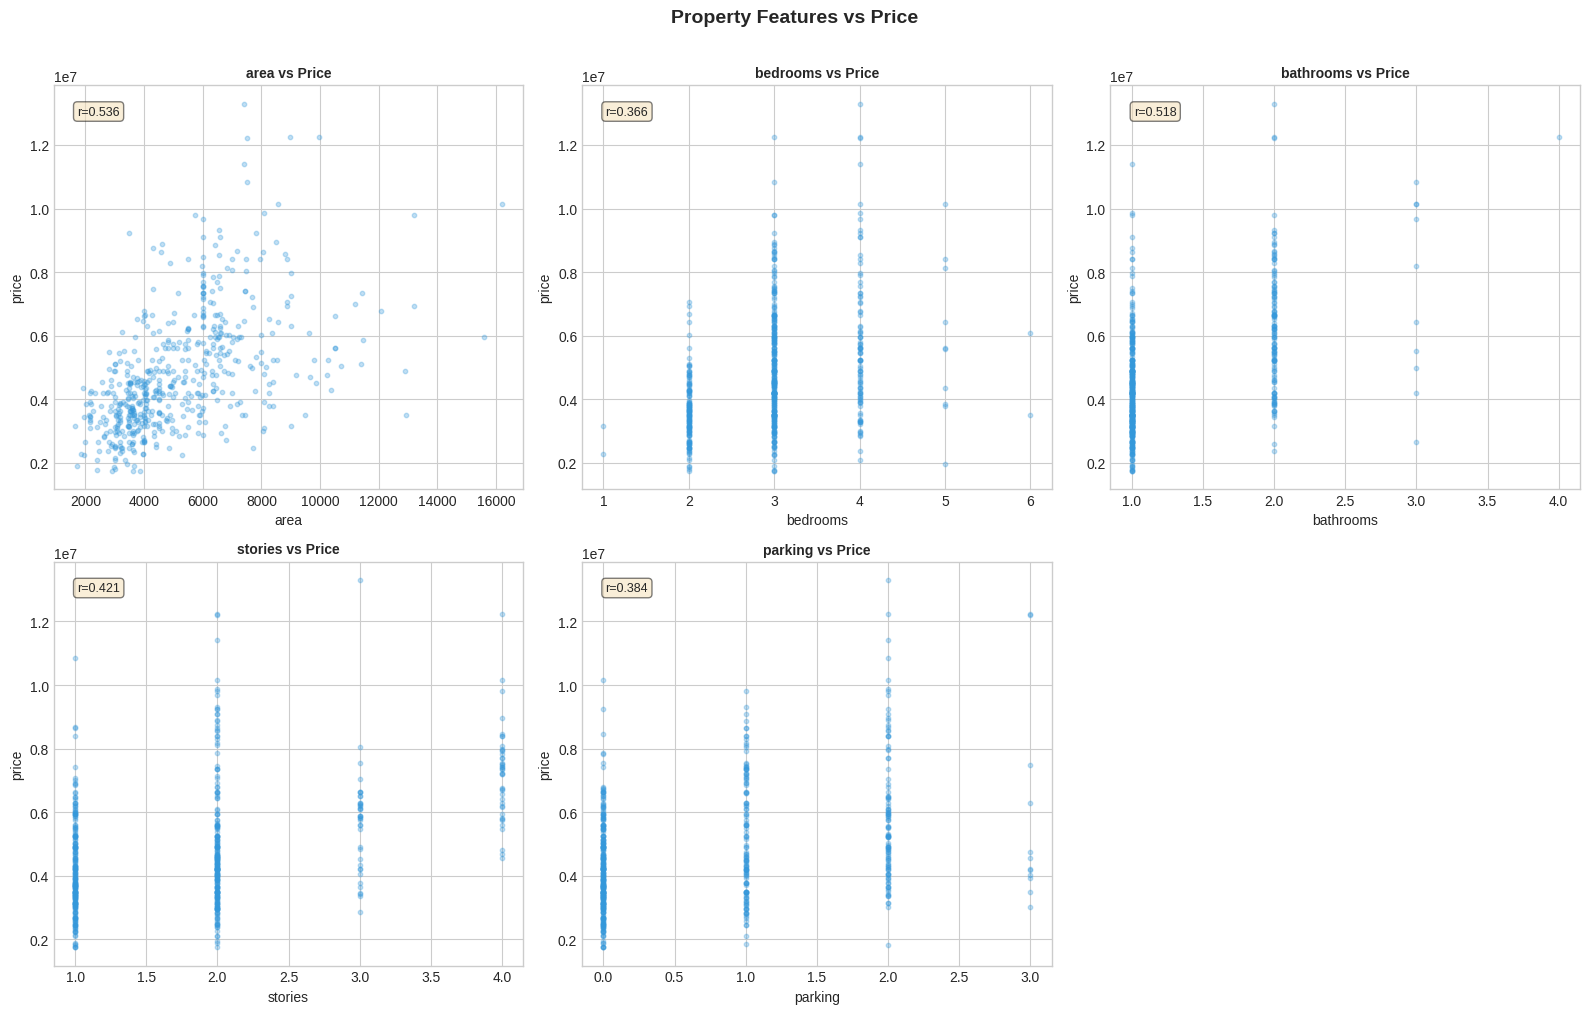

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index', 'unnamed: 0']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

if len(numeric_cols) > 0:
    plot_cols = numeric_cols[:6]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        axes[i].scatter(df[col], df[target_col], alpha=0.3, s=10, color='#3498db')
        axes[i].set_xlabel(col); axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{col} vs Price', fontsize=10, fontweight='bold')
        corr_val = df[[col, target_col]].corr().iloc[0, 1]
        axes[i].text(0.05, 0.95, f'r={corr_val:.3f}', transform=axes[i].transAxes, fontsize=9,
                     va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Property Features vs Price', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


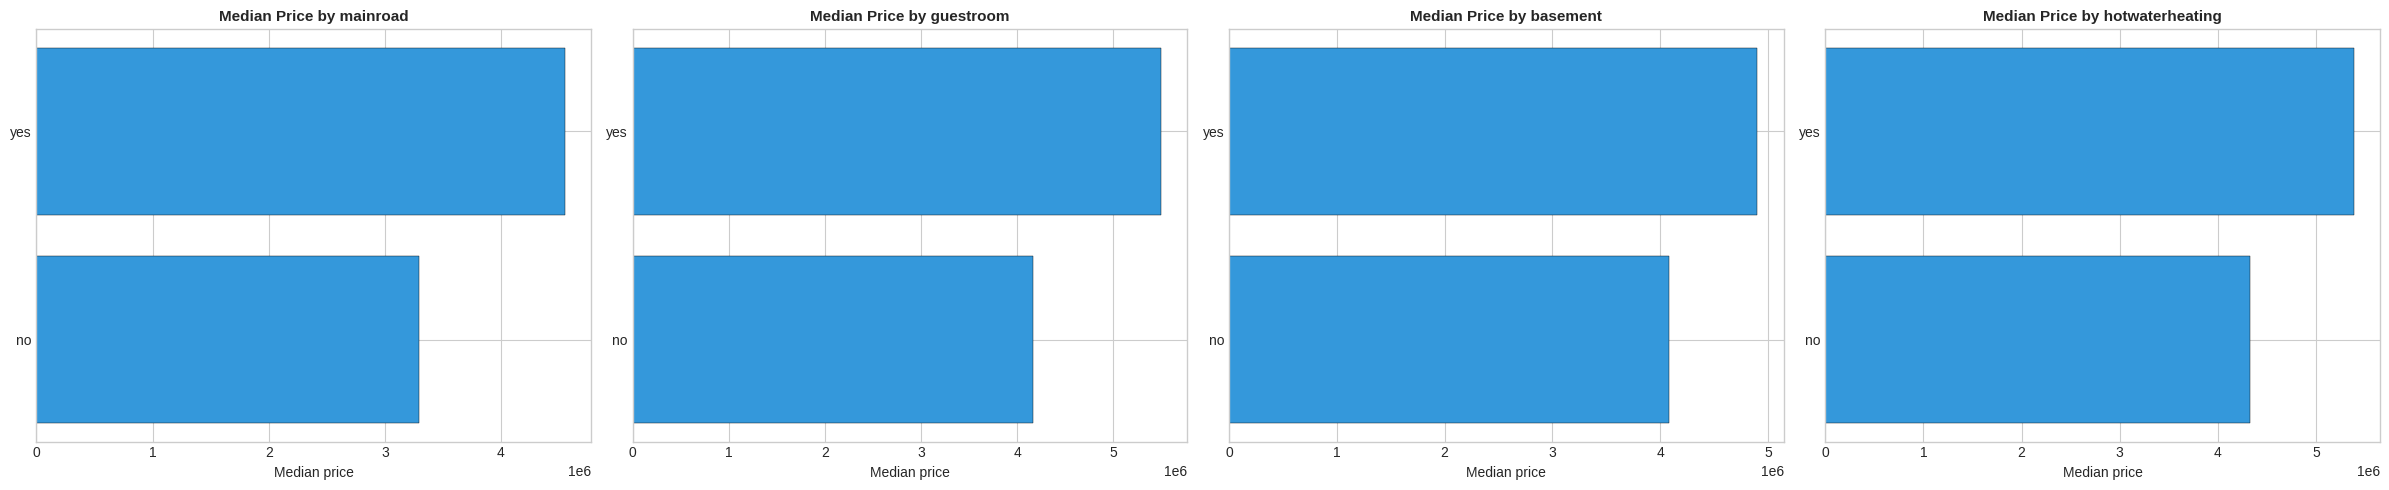

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if df[c].nunique() <= 20 and 'id' not in c.lower()]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:4]
    fig, axes = plt.subplots(1, min(len(plot_cats), 4), figsize=(6 * min(len(plot_cats), 4), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(plot_cats):
        means = df.groupby(col)[target_col].median().sort_values()
        axes[i].barh(means.index.astype(str), means.values, color='#3498db', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'Median Price by {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(f'Median {target_col}')
    plt.tight_layout(); plt.savefig('categorical_price.png', dpi=150, bbox_inches='tight'); plt.show()


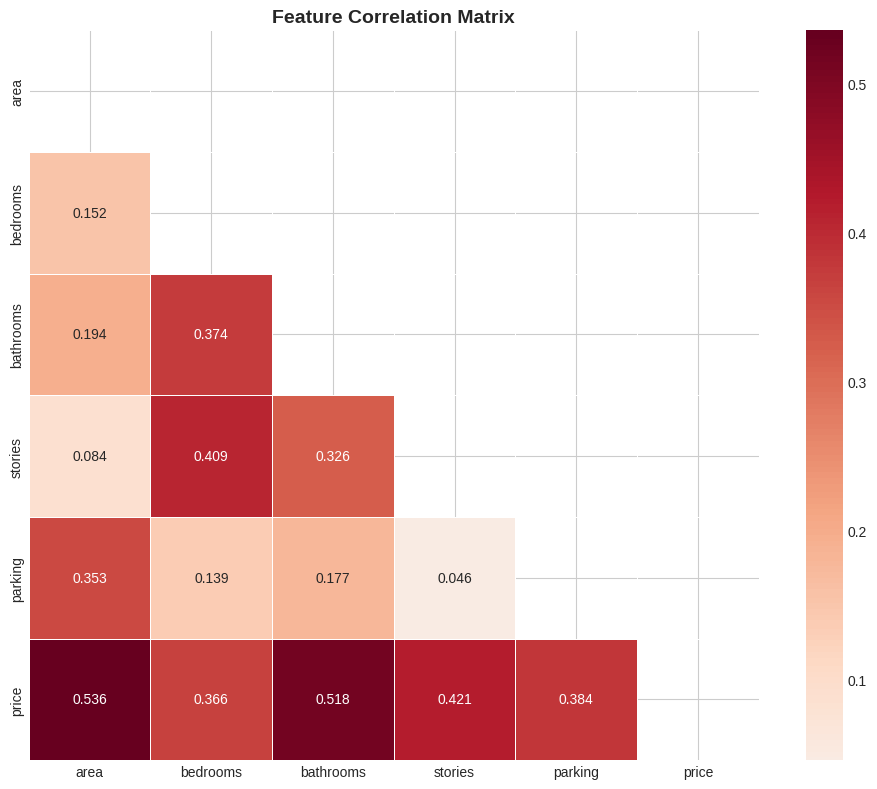

Correlations with price:
  area                           +0.5360
  bathrooms                      +0.5175
  stories                        +0.4207
  parking                        +0.3844
  bedrooms                       +0.3665


In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with price:")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:30s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

Property valuation benefits from:
- **Price per sqm** — normalised metric for comparability
- **Total rooms** — bedrooms + bathrooms combined
- **Luxury score** — count of premium amenities
- **Log-transform target** if skewed (common for price data)


In [9]:
df_model = df.copy()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)

drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

use_log = False
if abs(pd.Series(y).skew()) > 1 and (y > 0).all():
    y_orig = y.copy()
    y = np.log1p(y)
    use_log = True
    print(f"\nApplied log1p transform (skewness was {pd.Series(y_orig).skew():.2f})")

null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")


  Encoded 'mainroad': 2 classes
  Encoded 'guestroom': 2 classes
  Encoded 'basement': 2 classes
  Encoded 'hotwaterheating': 2 classes
  Encoded 'airconditioning': 2 classes
  Encoded 'prefarea': 2 classes
  Encoded 'furnishingstatus': 3 classes

Applied log1p transform (skewness was 1.21)

Feature matrix: (545, 12)


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Total rooms
bed_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['bedroom', 'bedrooms', 'bed'])]
bath_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['bathroom', 'bathrooms', 'bath'])]
if bed_cols and bath_cols:
    X['total_rooms'] = X[bed_cols[0]] + X[bath_cols[0]]
    composites_added.append('total_rooms')
    print(f"Created 'total_rooms'")

# Area per bedroom
area_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['area', 'sqft', 'size', 'lotarea'])]
if area_cols and bed_cols:
    X['area_per_bedroom'] = X[area_cols[0]] / (X[bed_cols[0]] + 1)
    composites_added.append('area_per_bedroom')
    print(f"Created 'area_per_bedroom'")

# Luxury/amenity count
amenity_cols = [c for c in feature_names if any(kw in c.lower() for kw in
                ['airconditioning', 'air', 'parking', 'garage', 'pool',
                 'guestroom', 'basement', 'hotwaterheating', 'prefarea'])]
if len(amenity_cols) >= 2:
    X['amenity_count'] = X[amenity_cols].sum(axis=1)
    composites_added.append('amenity_count')
    print(f"Created 'amenity_count' from {amenity_cols}")

# Stories × area interaction
stories_cols = [c for c in feature_names if 'stories' in c.lower() or 'story' in c.lower() or 'floors' in c.lower()]
if stories_cols and area_cols:
    X['total_built_area'] = X[stories_cols[0]] * X[area_cols[0]]
    composites_added.append('total_built_area')
    print(f"Created 'total_built_area'")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'total_rooms'
Created 'area_per_bedroom'
Created 'amenity_count' from ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']
Created 'total_built_area'

Total engineered: 4
Final feature count: 16


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBRegressor
    print("XGBoost loaded")
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
    print("LightGBM loaded")
except ImportError:
    LGBMRegressor = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1,
                                         n_jobs=-1, force_col_wise=True)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_rmse, fold_mae, fold_r2 = [], [], []
    fold_preds = np.zeros(len(y))
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        fold_preds[val_idx] = y_pred
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        fold_rmse.append(rmse); fold_mae.append(mae); fold_r2.append(r2)
        print(f"  Fold {fold_idx+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'rmse_mean': np.mean(fold_rmse), 'rmse_std': np.std(fold_rmse),
        'mae_mean': np.mean(fold_mae), 'mae_std': np.std(fold_mae),
        'r2_mean': np.mean(fold_r2), 'r2_std': np.std(fold_r2),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- RMSE: {np.mean(fold_rmse):.4f}  MAE: {np.mean(fold_mae):.4f}  R2: {np.mean(fold_r2):.4f}  Time: {elapsed:.2f}s")



Training: Ridge Regression
  Fold 1: RMSE=0.2409  MAE=0.1885  R2=0.6566
  Fold 2: RMSE=0.1882  MAE=0.1515  R2=0.6679
  Fold 3: RMSE=0.2121  MAE=0.1611  R2=0.6766
  -- RMSE: 0.2137  MAE: 0.1670  R2: 0.6670  Time: 0.03s

Training: Random Forest
  Fold 1: RMSE=0.2575  MAE=0.1997  R2=0.6074
  Fold 2: RMSE=0.1961  MAE=0.1472  R2=0.6394
  Fold 3: RMSE=0.2274  MAE=0.1668  R2=0.6282
  -- RMSE: 0.2270  MAE: 0.1712  R2: 0.6250  Time: 0.81s

Training: XGBoost
  Fold 1: RMSE=0.2650  MAE=0.2105  R2=0.5845
  Fold 2: RMSE=0.2142  MAE=0.1554  R2=0.5697
  Fold 3: RMSE=0.2462  MAE=0.1839  R2=0.5644
  -- RMSE: 0.2418  MAE: 0.1833  R2: 0.5729  Time: 0.36s

Training: LightGBM
  Fold 1: RMSE=0.2503  MAE=0.1964  R2=0.6293
  Fold 2: RMSE=0.1959  MAE=0.1493  R2=0.6401
  Fold 3: RMSE=0.2297  MAE=0.1684  R2=0.6208
  -- RMSE: 0.2253  MAE: 0.1714  R2: 0.6300  Time: 0.19s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'RMSE': f"{res['rmse_mean']:.4f} +/- {res['rmse_std']:.4f}",
        'MAE': f"{res['mae_mean']:.4f} +/- {res['mae_std']:.4f}",
        'R2': f"{res['r2_mean']:.4f} +/- {res['r2_std']:.4f}",
        'Time': f"{res['time']:.2f}s", 'R2_val': res['r2_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('R2_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'RMSE', 'MAE', 'R2', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
           Model              RMSE               MAE                R2  Time
Ridge Regression 0.2137 +/- 0.0215 0.1670 +/- 0.0157 0.6670 +/- 0.0082 0.03s
        LightGBM 0.2253 +/- 0.0224 0.1714 +/- 0.0193 0.6300 +/- 0.0079 0.19s
   Random Forest 0.2270 +/- 0.0251 0.1712 +/- 0.0216 0.6250 +/- 0.0132 0.81s
         XGBoost 0.2418 +/- 0.0210 0.1833 +/- 0.0225 0.5729 +/- 0.0085 0.36s

Best model: Ridge Regression


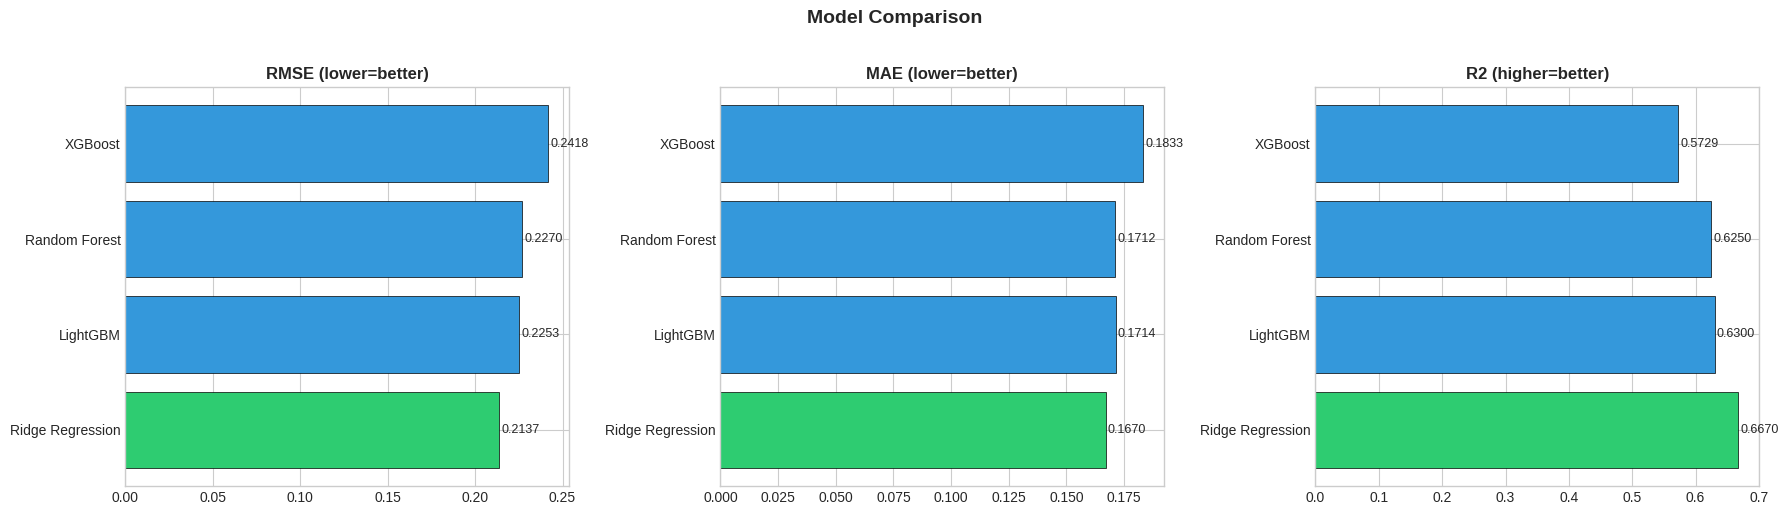

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['rmse_mean', 'mae_mean', 'r2_mean'],
                              ['RMSE (lower=better)', 'MAE (lower=better)', 'R2 (higher=better)']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v + 0.005 * max(vals), i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Residual Analysis

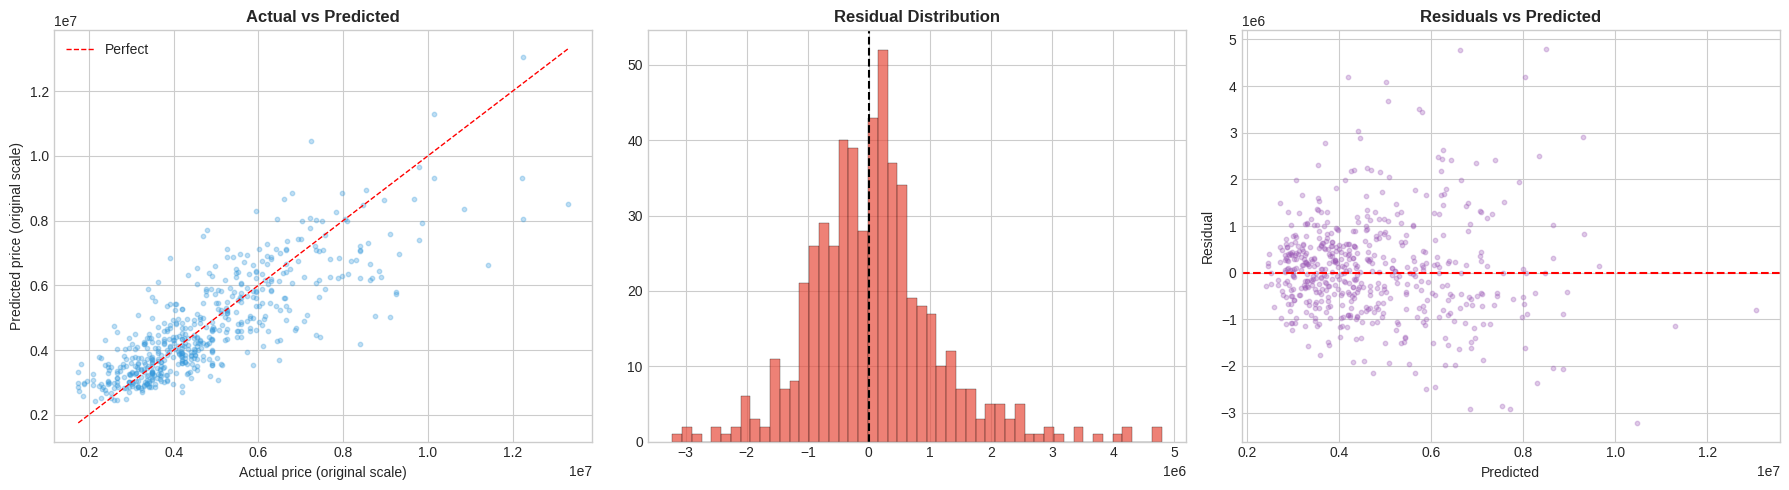

MAPE: 17.1%
Median APE: 12.9%


In [15]:
best_preds = results[best_model_name]['oof_preds']
if use_log:
    y_plot = np.expm1(y); pred_plot = np.expm1(best_preds)
    ylabel = f'{target_col} (original scale)'
else:
    y_plot = y; pred_plot = best_preds; ylabel = target_col
residuals = y_plot - pred_plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_plot, pred_plot, alpha=0.3, s=10, color='#3498db')
lims = [min(y_plot.min(), pred_plot.min()), max(y_plot.max(), pred_plot.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect')
axes[0].set_xlabel(f'Actual {ylabel}'); axes[0].set_ylabel(f'Predicted {ylabel}')
axes[0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold'); axes[0].legend()

axes[1].hist(residuals, bins=50, color='#e74c3c', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')

axes[2].scatter(pred_plot, residuals, alpha=0.3, s=10, color='#9b59b6')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel(f'Predicted'); axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
non_zero = np.abs(y_plot) > 1e-6
if non_zero.sum() > 0:
    mape = np.mean(np.abs(residuals[non_zero]) / np.abs(y_plot[non_zero])) * 100
    print(f"MAPE: {mape:.1f}%")
    median_ape = np.median(np.abs(residuals[non_zero]) / np.abs(y_plot[non_zero])) * 100
    print(f"Median APE: {median_ape:.1f}%")


## 8. Feature Importance & Policy Insights

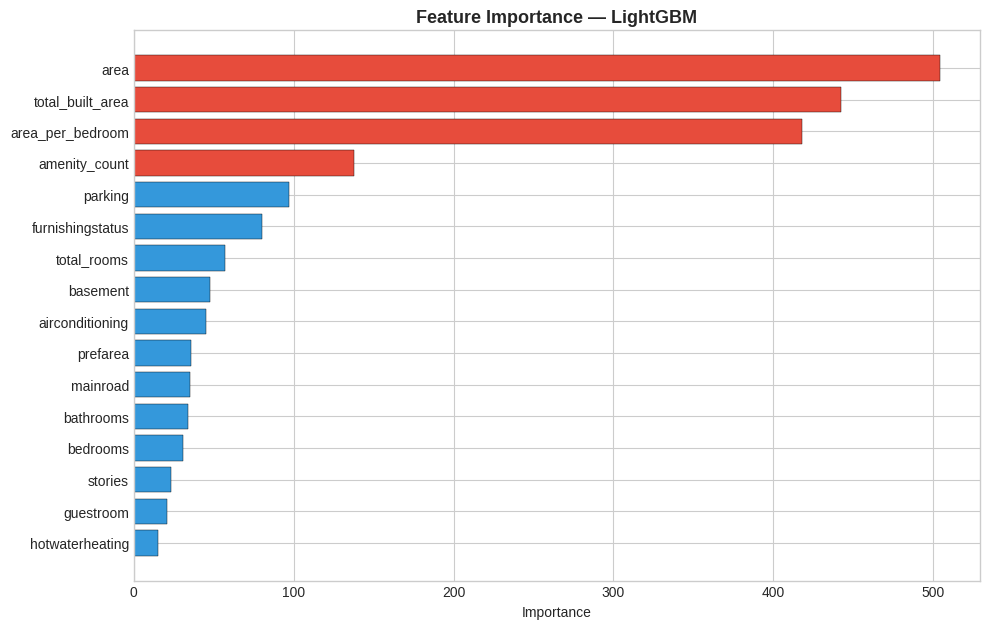

TOP 5 PREDICTIVE FEATURES
  area                            504.0000
  total_built_area                442.0000
  area_per_bedroom                418.0000
  amenity_count                   138.0000
  parking                         97.0000


In [16]:
tree_models = {k: v for k, v in models.items() if k != 'Ridge Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['r2_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")


## 9. Deployment Readiness & Production Considerations

In [17]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  RMSE:                 {best_res['rmse_mean']:.4f}")
print(f"  MAE:                  {best_res['mae_mean']:.4f}")
print(f"  R-squared:            {best_res['r2_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Log transform:        {'Yes' if use_log else 'No'}")
print(f"  CV strategy:          3-fold")
print("=" * 60)
checks = {
    'R2 > 0.50': best_res['r2_mean'] > 0.50,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Residual analysis done': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Ridge Regression
  RMSE:                 0.2137
  MAE:                  0.1670
  R-squared:            0.6670
  Training time:        0.0s
  Feature count:        16
  Dataset rows:         545
  Log transform:        Yes
  CV strategy:          3-fold

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] R2 > 0.50
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Residual analysis done
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [18]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: CoreLogic/RP Data property database, state land registries
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (property attributes, sales history, ABS census)
   Schedule: Daily (new listings), weekly (sales settlements)

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time AVM (<500ms per property)
   Batch: Monthly portfolio revaluation for lenders
   Output: Point estimate + confidence interval + comparable sales

3. INTEGRATION POINTS
   Banks: Automated Valuation Model (AVM) for mortgage origination
   Government: FHOG/Help to Buy eligibility screening
   Revenue: Stamp duty revenue forecasting by LGA
   APRA: Mortgage book stress testing, LVR monitoring
   Consumer: Property report for buyers (realestate.com.au integration)

4. GOVERNANCE
   Validation: Backtesting against actual sale prices (settlement data)
   Bias: Monitor for systematic over/under-valuation by suburb, property type
   Fairness: Ensure no discrimination by postcode (proxy for demographics)
   Compliance: Australian Property Institute valuation standards
   Transparency: Comparable sales and feature contributions disclosed

5. MONITORING & RETRAINING
   Drift: PSI on property features and market prices monthly
   Performance: MAE/MAPE against settled sales quarterly
   Retraining: Quarterly with latest 12 months of sales data
   Market regime: Interest rate change triggers model recalibration
   Stress testing: APRA-mandated housing downturn scenarios

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: CoreLogic/RP Data property database, state land registries
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (property attributes, sales history, ABS census)
   Schedule: Daily (new listings), weekly (sales settlements)

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time AVM (<500ms per property)
   Batch: Monthly portfolio revaluation for lenders
   Output: Point estimate + confidence interval + comparable sales

3. INTEGRATION POINTS
   Banks: Automated Valuation Model (AVM) for mortgage origination
   Government: FHOG/Help to Buy eligibility screening
   Revenue: Stamp duty revenue forecasting by LGA
   APRA: Mortgage book stress testing, LVR monitoring
   Consumer: Property report for buyers (realestate.com.au integration)

4. GOVERNANCE
   Validation: Backtesting against actual sale prices (settlement data)
   Bias: Monitor for systematic over